# CNN - Clasificacion de Animales v2

Mejoras respecto a v1:
- **SE blocks** (channel attention) — aprende a ignorar fondos irrelevantes
- **MixUp augmentation** — mezcla imágenes para forzar generalización
- **Cosine decay LR** — mejor schedule que ReduceLROnPlateau
- **Label smoothing** — evita overconfidence

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
try:
    import enable_gpu
    enable_gpu.enable()
except Exception:
    pass
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, LeakyReLU, GlobalAveragePooling2D,
    Multiply, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy

## 1. Cargar dataset

In [3]:
CARPETA_DATASET = os.path.join(os.getcwd(), "dataset")
TAMANO = 64
SEMILLA = 42
BATCH_SIZE = 64
EPOCHS = 30
MIXUP_ALPHA = 0.2
LABEL_SMOOTH = 0.05

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

CLASES = sorted(os.listdir(CARPETA_DATASET))
print(f"Clases: {CLASES}")

Clases: ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']


In [4]:
X, y = [], []

for idx, clase in enumerate(CLASES):
    carpeta = os.path.join(CARPETA_DATASET, clase)
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"  {clase}: {len(archivos)}")
    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        try:
            img = load_img(ruta, target_size=(TAMANO, TAMANO))
            X.append(img_to_array(img))
            y.append(idx)
        except Exception as e:
            print(f"  [WARN] {archivo}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)
print(f"\nTotal: {len(X)}, forma: {X.shape}")

  aranas: 5000


/home/acostkdev/Documents/systems/git/AI/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  ballenas: 5000
  changos: 5000
  pajaros: 5000
  ranas: 5000

Total: 25000, forma: (25000, 64, 64, 3)


In [5]:
X = X / 255.0
y_cat = to_categorical(y, num_classes=len(CLASES))

In [6]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y_cat, test_size=0.2, random_state=SEMILLA, stratify=y
)
train_X, val_X, train_y, val_y = train_test_split(
    train_X, train_y, test_size=0.2, random_state=SEMILLA,
    stratify=np.argmax(train_y, axis=1)
)

print(f"Train: {train_X.shape}")
print(f"Val:   {val_X.shape}")
print(f"Test:  {test_X.shape}")

Train: (16000, 64, 64, 3)
Val:   (4000, 64, 64, 3)
Test:  (5000, 64, 64, 3)


## 2. Augmentación

- **Fondo aleatorio**: detecta fondos claros/uniformes (como el blanco de las ranas) y los
  reemplaza con colores aleatorios cada época, forzando al modelo a ignorar el fondo.
- **MixUp**: interpola pares de imágenes para que el modelo generalice mejor.

In [7]:
class MixUpSequence(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size, alpha=MIXUP_ALPHA, shuffle=True):
        self.X, self.y = X, y
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.floor(len(self.X) / self.batch_size))

    def _randomizar_fondo(self, batch_X):
        B, H, W, C = batch_X.shape
        colores_fondo = np.array([
            [0.3, 0.7, 0.3], [0.2, 0.5, 0.2], [0.4, 0.8, 0.4],
            [0.3, 0.6, 0.8], [0.2, 0.4, 0.6], [0.5, 0.7, 0.9],
            [0.6, 0.5, 0.3], [0.5, 0.4, 0.2], [0.7, 0.6, 0.4],
            [1.0, 1.0, 1.0], [0.9, 0.9, 0.9],
        ], dtype=np.float32)
        for i in range(B):
            gray = np.mean(batch_X[i], axis=2)
            gx = np.abs(np.diff(gray, axis=1, append=0))
            gy = np.abs(np.diff(gray, axis=0, append=0))
            edge = ((gx + gy) > 0.06).astype(np.float32)
            for _ in range(4):
                d = edge.copy()
                d[:-1] = np.maximum(d[:-1], edge[1:])
                d[1:] = np.maximum(d[1:], edge[:-1])
                d[:, :-1] = np.maximum(d[:, :-1], edge[:, 1:])
                d[:, 1:] = np.maximum(d[:, 1:], edge[:, :-1])
                edge = d
            for _ in range(2):
                edge = (edge[:-2] + edge[1:-1] + edge[2:]) / 3
                edge = (edge[:, :-2] + edge[:, 1:-1] + edge[:, 2:]) / 3
                if edge.shape[0] < H:
                    edge = np.pad(edge, ((0, H - edge.shape[0]), (0, W - edge.shape[1])), mode='edge')
            color = colores_fondo[np.random.randint(len(colores_fondo))].reshape(1, 1, 3)
            batch_X[i] = batch_X[i] * edge[:, :, np.newaxis] + color * (1 - edge[:, :, np.newaxis])
        return batch_X

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X = self.X[batch_idx].copy()
        batch_y = self.y[batch_idx].copy()

        batch_X = self._randomizar_fondo(batch_X)

        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
            perm = np.random.permutation(len(batch_X))
            batch_X = lam * batch_X + (1 - lam) * batch_X[perm]
            batch_y = lam * batch_y + (1 - lam) * batch_y[perm]

        return batch_X, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = MixUpSequence(train_X, train_y, BATCH_SIZE, alpha=MIXUP_ALPHA)
print(f"MixUpSequence — steps_per_epoch: {len(train_gen)}")

MixUpSequence — steps_per_epoch: 250


## 3. SE Block (Squeeze-and-Excitation)

El SE block aprende pesos por canal: puede "apagar" canales que detectan fondo
y "amplificar" los que detectan el objeto (ballena, araña, etc.).

In [8]:
def se_block(x, reduction=8):
    channels = int(x.shape[-1])
    se = GlobalAveragePooling2D()(x)
    se = Dense(max(channels // reduction, 4), activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)
    se = Reshape((1, 1, channels))(se)
    return Multiply()([x, se])

## 4. Arquitectura del modelo

In [9]:
inp = Input((TAMANO, TAMANO, 3))

# Bloque 1: 32 filtros
x = Conv2D(32, (3, 3), padding='same')(inp)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)
x = se_block(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.2)(x)

# Bloque 2: 64 filtros
x = Conv2D(64, (3, 3), padding='same')(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)
x = se_block(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.2)(x)

# Bloque 3: 128 filtros
x = Conv2D(128, (3, 3), padding='same')(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)
x = se_block(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.2)(x)

# Clasificador
x = Flatten()(x)
x = Dense(256)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)
x = Dropout(0.35)(x)
x = Dense(128)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)
x = Dropout(0.35)(x)
out = Dense(len(CLASES), activation='softmax')(x)

modelo = Model(inp, out)
modelo.summary()

modelo.compile(
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        576 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 2,232,257 (8.52 MB)

 Trainable params: 2,231,041 (8.51 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 5. Cosine Decay LR

Reduce la learning rate suavemente siguiendo un coseno, en vez de reducir
a saltos cuando el modelo se estanca.

In [10]:
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=len(train_gen) * EPOCHS,
    alpha=1e-4
)
modelo.optimizer.learning_rate = cosine_decay

## 6. Callbacks

In [11]:
callbacks = [
    ModelCheckpoint(
        'modelo_animales.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    )
]

## 7. Entrenamiento

In [12]:
historial = modelo.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=EPOCHS,
    validation_data=(val_X, val_y),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


/home/acostkdev/Documents/systems/git/AI/.venv/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.5860 - loss: 1.3954
Epoch 1: val_loss improved from None to 2.82955, saving model to modelo_animales.keras

Epoch 1: finished saving model to modelo_animales.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 132s 505ms/step - accuracy: 0.6566 - loss: 1.1796 - val_accuracy: 0.3002 - val_loss: 2.8295
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7587 - loss: 0.9162
Epoch 2: val_loss improved from 2.82955 to 1.04606, saving model to modelo_animales.keras

Epoch 2: finished saving model to modelo_animales.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 118s 473ms/step - accuracy: 0.7682 - loss: 0.9019 - val_accuracy: 0.6090 - val_loss: 1.0461
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.7921 - loss: 0.8579
Epoch 3: val_loss improved from 1.04606 to 0.66891, saving model to modelo_animales.keras

Epoch 3: finished saving model to modelo_animales.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 123s 492ms/step - accuracy: 0.7987 - l

## 8. Evaluacion

In [13]:
test_loss, test_acc = modelo.evaluate(test_X, test_y, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.9452
Test loss: 0.3794


In [14]:
preds = modelo.predict(test_X)
preds_clase = np.argmax(preds, axis=1)
test_clase = np.argmax(test_y, axis=1)

print(classification_report(test_clase, preds_clase, target_names=CLASES))

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step
              precision    recall  f1-score   support

      aranas       0.96      0.91      0.93      1000
    ballenas       0.97      0.96      0.96      1000
     changos       0.93      0.93      0.93      1000
     pajaros       0.89      0.96      0.92      1000
       ranas       0.98      0.96      0.97      1000

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



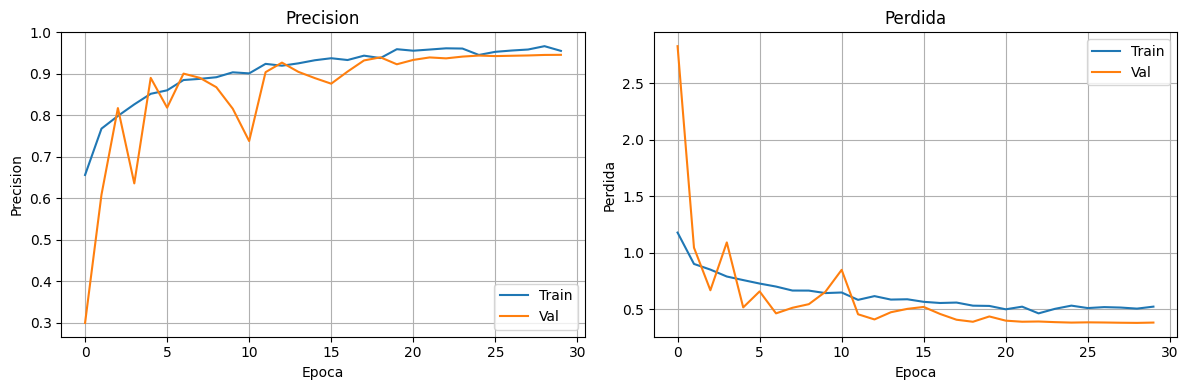

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Train')
plt.plot(historial.history['val_accuracy'], label='Val')
plt.title('Precision')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Train')
plt.plot(historial.history['val_loss'], label='Val')
plt.title('Perdida')
plt.xlabel('Epoca')
plt.ylabel('Perdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('grafica_entrenamiento.png', dpi=150)
plt.show()

In [16]:
modelo.save('modelo_animales.h5')
print(f"Modelo guardado en: {os.path.join(os.getcwd(), 'modelo_animales.h5')}")

Modelo guardado en: /home/acostkdev/Documents/systems/git/AI/project/project2/modelo_animales.h5


In [17]:
print("=== ENTRENAMIENTO COMPLETADO ===")

=== ENTRENAMIENTO COMPLETADO ===


## 9. Prediccion interactiva

In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from io import BytesIO
from PIL import Image
import sys
sys.path.insert(0, os.getcwd())
from procesar_imagen import remover_fondo

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Seleccionar imagen',
    style={'button_color': '#4CAF50'}
)
output = widgets.Output()

def predecir_imagen(change):
    with output:
        clear_output()
        archivos = change['new']
        if not archivos:
            return
        for info in archivos:
            if isinstance(info, dict):
                nombre = info.get('name', 'imagen')
                content = info.get('content', None)
                if content is None:
                    continue
            else:
                nombre = 'imagen'
                content = info
            img_pil = Image.open(BytesIO(content)).convert('RGB')
            img_resized = img_pil.resize((TAMANO, TAMANO))
            img_sf = remover_fondo(img_resized)
            def _pred(x): return modelo.predict(x, verbose=0)[0]
            pred_orig = _pred(np.expand_dims(np.array(img_resized, dtype=np.float32) / 255.0, axis=0))
            pred_sf = _pred(np.expand_dims(np.array(img_sf, dtype=np.float32) / 255.0, axis=0))
            pred = pred_sf if pred_sf.max() >= pred_orig.max() else pred_orig
            idx = np.argmax(pred)
            confianza = pred[idx]
            print(f"Archivo: {nombre}")
            print(f"Prediccion: {CLASES[idx]} ({confianza:.1%})")
            print()
            print("Probabilidades:")
            for i, clase in enumerate(CLASES):
                barra = '█' * int(pred[i] * 40)
                print(f"  {clase:10s} {pred[i]:7.1%} {barra}")
            print()
            display(img_pil.resize((200, 200)))

uploader.observe(predecir_imagen, names='value')
display(uploader, output)

FileUpload(value=(), accept='image/*', description='Seleccionar imagen', style=ButtonStyle(button_color='#4CAF…

Output()